In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [ ]:
import pandas as pd

df = pd.read_csv(path + "/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
print(df["sentiment"].unique())

['positive' 'negative']


In [ ]:
from sklearn.model_selection import train_test_split

df["sentiment"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

df["sentiment"]

,sentiment
0,1
1,1
2,1
3,0
4,1
...,...
49995,1
49996,0
49997,0
49998,0


In [ ]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df["review"],
    df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]
)

X_train.head()
## run this cell to use countvectorizer
# countvectorizer
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=1000 , stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

X_train_vec

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1860435 stored elements and shape (40000, 1000)>

In [60]:
## Run this cell to use tdidfvectorizer
# TD-IDF vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000 , stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

X_train_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1860435 stored elements and shape (40000, 1000)>

## we can see that dtype of X-train-vec is "int64" , pytorch neural network common dtype is "float64" , so therefore type conversion is required

In [53]:
## helper function
#training and testing loop
train_acc , test_acc = [],[]

def train_test_loop(model , optimizer, loss_fn , train_dataloader, test_dataloader ,epochs):
  for epoch in range(epochs):
    train_loss = 0
    train_total = 0
    train_correct = 0
    for X_batch, y_batch in train_dataloader:

            y_batch = y_batch.float().unsqueeze(1)

            logits = model(X_batch)

            loss = loss_fn(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            preds = (torch.sigmoid(logits) > 0.5).float()

            train_correct += (preds == y_batch).sum().item()
            train_total += y_batch.size(0)

    train_epoch_acc = train_correct / train_total
    train_acc.append(train_epoch_acc)

    model.eval()

    test_loss = 0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for X_batch, y_batch in test_dataloader:

            y_batch = y_batch.float().unsqueeze(1)

            logits = model(X_batch)

            loss = loss_fn(logits, y_batch)

            test_loss += loss.item()

            preds = (torch.sigmoid(logits) > 0.5).float()

            test_correct += (preds == y_batch).sum().item()
            test_total += y_batch.size(0)

    test_epoch_acc = test_correct / test_total
    test_acc.append(test_epoch_acc)

    if epoch %5 == 0:
      print(
          f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss/len(train_dataloader):.4f} | "
          f"Train Acc: {train_epoch_acc:.4f} | "
          f"Test Loss: {test_loss/len(test_dataloader):.4f} | "
          f"Test Acc: {test_epoch_acc:.4f}"
      )
  return train_acc,test_acc
# Visualizing the acc curves to find best epoch for early stopping

import matplotlib.pyplot as plt

def plot_accuracy_curves(train_acc, test_acc):

    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_acc,
        label="Train Accuracy"
    )

    plt.plot(
        epochs,
        test_acc,
        label="Test Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Testing Accuracy")
    plt.legend()
    plt.grid(True)

    plt.show()



In [39]:
import torch
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

X_train_tensor = torch.tensor(X_train_vec.toarray()).float()
y_train_tensor = torch.tensor(y_train.values).float()
X_test_tensor = torch.tensor(X_test_vec.toarray()).float()
y_test_tensor = torch.tensor(y_test.values).float()

train_dataset = TensorDataset(
                X_train_tensor,
                y_train_tensor
)

test_dataset = TensorDataset(
                X_test_tensor,
                y_test_tensor
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

Epoch 01 | Train Loss: 0.4163 | Train Acc: 0.8238 | Test Loss: 0.3561 | Test Acc: 0.8575
Epoch 06 | Train Loss: 0.3285 | Train Acc: 0.8629 | Test Loss: 0.3328 | Test Acc: 0.8625
Epoch 11 | Train Loss: 0.3264 | Train Acc: 0.8640 | Test Loss: 0.3369 | Test Acc: 0.8606
Epoch 16 | Train Loss: 0.3255 | Train Acc: 0.8650 | Test Loss: 0.3423 | Test Acc: 0.8616
Epoch 21 | Train Loss: 0.3257 | Train Acc: 0.8651 | Test Loss: 0.3456 | Test Acc: 0.8560


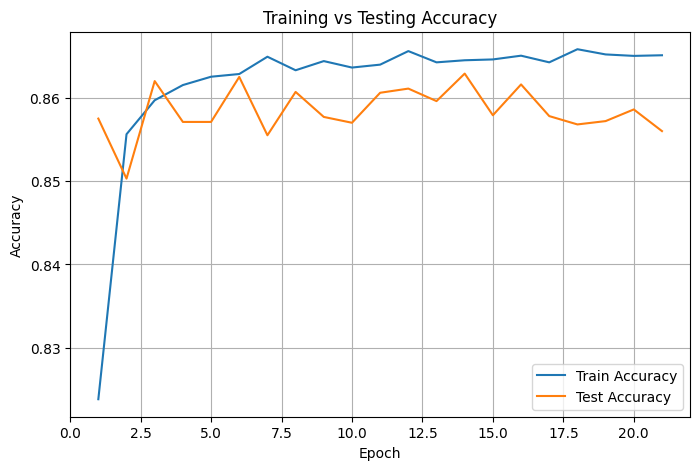

In [54]:
# building  a  pytorch neural network

import torch.nn as nn

class Model_0(nn.Module): #starting with linear layer
  """
  this is a model with linear layer and countvectorizer as feature extraction
  """
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=1000, out_features=1)

  def forward(self, x):
    return self.layer_1(x)

model_0 = Model_0()
epochs = 21

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

train_acc_model_0,test_acc_model_0 = train_test_loop(model_0, optimizer, loss_fn, train_dataloader, test_dataloader, epochs)
plot_accuracy_curves(train_acc_model_0, test_acc_model_0)


Epoch 01 | Train Loss: 0.3753 | Train Acc: 0.8403 | Test Loss: 0.3251 | Test Acc: 0.8617
Epoch 06 | Train Loss: 0.1030 | Train Acc: 0.9688 | Test Loss: 0.4165 | Test Acc: 0.8515
Epoch 11 | Train Loss: 0.0088 | Train Acc: 0.9989 | Test Loss: 0.7339 | Test Acc: 0.8446
Epoch 16 | Train Loss: 0.0018 | Train Acc: 0.9998 | Test Loss: 0.9040 | Test Acc: 0.8469
Epoch 21 | Train Loss: 0.0009 | Train Acc: 0.9999 | Test Loss: 1.0208 | Test Acc: 0.8496


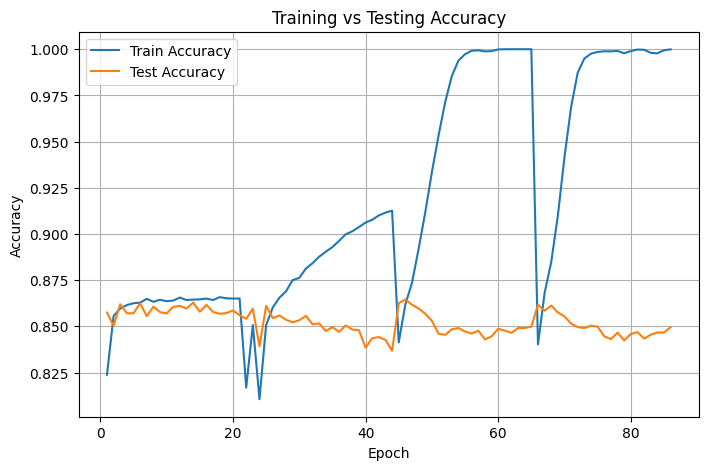

In [59]:
# model_1 with Relu() layer

class Model_1(nn.Module):
  """
  this is a model with non-linear layer and countvectorizer as feature extraction
  """
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Sequential(
            nn.Linear(1000, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

  def forward(self, x):
    return self.layer1(x)

model_1 = Model_1()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)
epochs = 21
train_acc_model_1,test_acc_model_1 = train_test_loop(model_1, optimizer, loss_fn, train_dataloader, test_dataloader, epochs)
plot_accuracy_curves(train_acc_model_1, test_acc_model_1)

Epoch 01 | Train Loss: 0.4158 | Train Acc: 0.8240 | Test Loss: 0.3563 | Test Acc: 0.8558
Epoch 06 | Train Loss: 0.3287 | Train Acc: 0.8639 | Test Loss: 0.3373 | Test Acc: 0.8595
Epoch 11 | Train Loss: 0.3256 | Train Acc: 0.8636 | Test Loss: 0.3375 | Test Acc: 0.8612
Epoch 16 | Train Loss: 0.3257 | Train Acc: 0.8661 | Test Loss: 0.3481 | Test Acc: 0.8564
Epoch 21 | Train Loss: 0.3255 | Train Acc: 0.8648 | Test Loss: 0.3502 | Test Acc: 0.8555


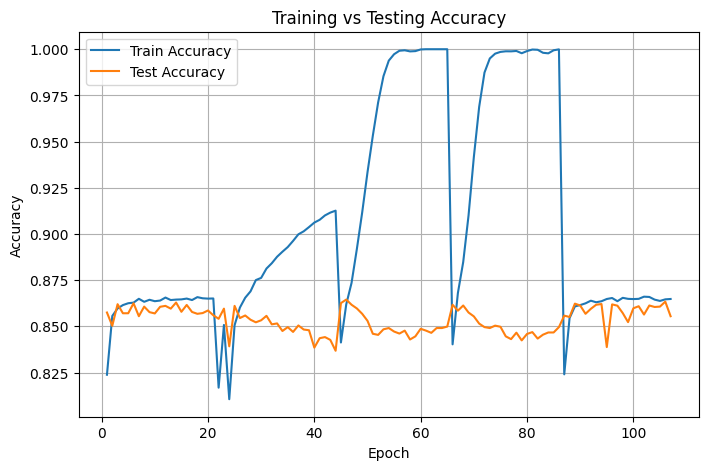

In [61]:

import torch.nn as nn

class Model_0(nn.Module):
  """
  this is a model with linear layer and tdidf as feature extraction
  """
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=1000, out_features=1)

  def forward(self, x):
    return self.layer_1(x)

model_0 = Model_0()
epochs = 21

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

train_acc_model_0,test_acc_model_0 = train_test_loop(model_0, optimizer, loss_fn, train_dataloader, test_dataloader, epochs)
plot_accuracy_curves(train_acc_model_0, test_acc_model_0)

Epoch 01 | Train Loss: 0.3762 | Train Acc: 0.8396 | Test Loss: 0.3267 | Test Acc: 0.8603
Epoch 06 | Train Loss: 0.1037 | Train Acc: 0.9685 | Test Loss: 0.4148 | Test Acc: 0.8489
Epoch 11 | Train Loss: 0.0075 | Train Acc: 0.9992 | Test Loss: 0.7329 | Test Acc: 0.8462
Epoch 16 | Train Loss: 0.0062 | Train Acc: 0.9987 | Test Loss: 0.9401 | Test Acc: 0.8464
Epoch 21 | Train Loss: 0.0011 | Train Acc: 0.9999 | Test Loss: 1.0375 | Test Acc: 0.8499


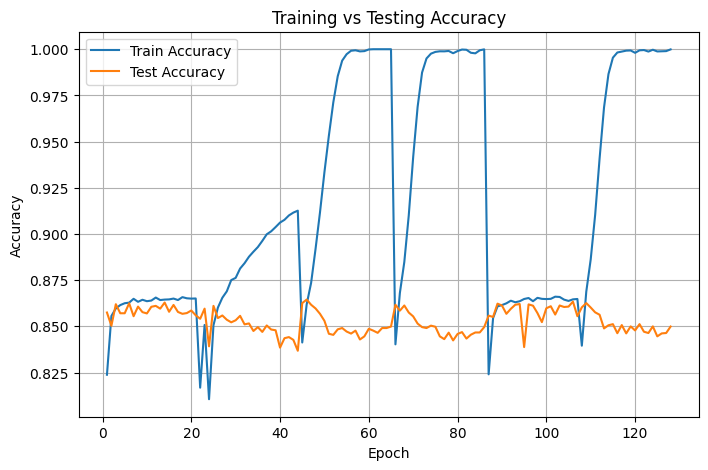

In [62]:
class Model_1(nn.Module):
  """
  this is a model with non-linear layer and tdidfvectorizer as feature extraction
  """
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Sequential(
            nn.Linear(1000, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

  def forward(self, x):
    return self.layer1(x)

model_1 = Model_1()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)
epochs = 21
train_acc_model_1,test_acc_model_1 = train_test_loop(model_1, optimizer, loss_fn, train_dataloader, test_dataloader, epochs)
plot_accuracy_curves(train_acc_model_1, test_acc_model_1)

In [66]:
# lets build with machine_learning technique
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

model_2 = Pipeline(
    [
        ("vectorizer", TfidfVectorizer(max_features=1000 , stop_words="english")),
        ("logistic", LogisticRegression())
    ]
)

model_2.fit(X_train,y_train)
y_pred = model_2.predict(X_test)
acc_model_2 = accuracy_score(y_test,y_pred)

In [67]:
print(acc_model_2)

0.8657
